# Simple Momentum and Contrarian Trading Strategies

This notebook is for educational purposes only. It is not financial advice. The strategies shown here are simplified examples and ignore important real-world factors such as transaction costs, bid-ask spreads, slippage, execution delay, position sizing, and risk management.


## Introduction

Simple momentum and simple contrarian strategies are among the most widely discussed trading strategy ideas.

They are closely related, but they take opposite views of recent price movement.

A **momentum** strategy assumes that recent price movement will continue.

- if the recent return is positive, go long
- if the recent return is negative, go short

A **contrarian** strategy assumes that recent price movement will reverse.

- if the recent return is positive, go short
- if the recent return is negative, go long

Coding-wise, the difference between a simple momentum strategy and a simple contrarian strategy can be as small as changing one sign.

```python
momentum_position = np.sign(recent_return)
contrarian_position = -np.sign(recent_return)
```


## Why These Strategies Are Risky as Standalone Systems

Although momentum and contrarian strategies are popular concepts, very simple versions of these strategies are unlikely to be profitable on their own.

The main reason is that they can lead to excessive trading. For example, if a strategy changes position every time a one-hour candle changes direction, it may generate many trades.

In real markets, every trade may involve:

- bid-ask spread
- commission
- slippage
- market impact
- execution delay

A strategy that looks acceptable before costs may become unprofitable after costs.

This is especially important for short timeframes such as hourly candles, because trading frequency can become high.

In later notebooks, we will test these strategies more formally and include trading costs.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12, 6)


## Small Example of Hourly Candle Returns

To understand the strategy logic, we do not need real market data yet. We can start with a small artificial example of hourly returns. Each row represents one completed hourly candle.


In [2]:
example = pd.DataFrame({
    "hour": pd.date_range("2024-01-01 09:00", periods=10, freq="h"),
    "return": [0.002, -0.001, -0.003, 0.004, 0.001, -0.002, 0.003, 0.002, -0.001, -0.004]
})

example.set_index("hour", inplace=True)
example


,return
hour,
2024-01-01 09:00:00,0.002
2024-01-01 10:00:00,-0.001
2024-01-01 11:00:00,-0.003
2024-01-01 12:00:00,0.004
2024-01-01 13:00:00,0.001
2024-01-01 14:00:00,-0.002
2024-01-01 15:00:00,0.003
2024-01-01 16:00:00,0.002
2024-01-01 17:00:00,-0.001


Positive returns represent green candles. Negative returns represent red candles.


## One-Bar Momentum Strategy

The simplest momentum strategy looks only at the most recent completed candle.

The rule is:

- if the previous candle return was positive, go long for the next candle
- if the previous candle return was negative, go short for the next candle

In code, the position is:

```python
position = np.sign(return)
```

However, to avoid look-ahead bias, the position must be shifted by one period before calculating strategy returns.


In [3]:
example["momentum_position_1"] = np.sign(example["return"])
example["momentum_strategy_1"] = example["momentum_position_1"].shift(1) * example["return"]

example


,return,momentum_position_1,momentum_strategy_1
hour,,,
2024-01-01 09:00:00,0.002,1.0,NaN
2024-01-01 10:00:00,-0.001,-1.0,-0.001
2024-01-01 11:00:00,-0.003,-1.0,0.003
2024-01-01 12:00:00,0.004,1.0,-0.004
2024-01-01 13:00:00,0.001,1.0,0.001
2024-01-01 14:00:00,-0.002,-1.0,-0.002
2024-01-01 15:00:00,0.003,1.0,-0.003
2024-01-01 16:00:00,0.002,1.0,0.002
2024-01-01 17:00:00,-0.001,-1.0,-0.001


The signal is generated from a completed candle. The strategy return is earned on the following candle. This is why `.shift(1)` is required.


## One-Bar Contrarian Strategy

The simplest contrarian strategy does the opposite.

The rule is:

- if the previous candle return was positive, go short for the next candle
- if the previous candle return was negative, go long for the next candle

In code, this is just the negative of the momentum position:

```python
contrarian_position = -momentum_position
```


In [4]:
example["contrarian_position_1"] = -np.sign(example["return"])
example["contrarian_strategy_1"] = example["contrarian_position_1"].shift(1) * example["return"]

example


,return,momentum_position_1,momentum_strategy_1,contrarian_position_1,contrarian_strategy_1
hour,,,,,
2024-01-01 09:00:00,0.002,1.0,NaN,-1.0,NaN
2024-01-01 10:00:00,-0.001,-1.0,-0.001,1.0,0.001
2024-01-01 11:00:00,-0.003,-1.0,0.003,1.0,-0.003
2024-01-01 12:00:00,0.004,1.0,-0.004,-1.0,0.004
2024-01-01 13:00:00,0.001,1.0,0.001,-1.0,-0.001
2024-01-01 14:00:00,-0.002,-1.0,-0.002,1.0,0.002
2024-01-01 15:00:00,0.003,1.0,-0.003,-1.0,0.003
2024-01-01 16:00:00,0.002,1.0,0.002,-1.0,-0.002
2024-01-01 17:00:00,-0.001,-1.0,-0.001,1.0,0.001


This shows the close relationship between the two strategy types. Momentum follows recent movement. Contrarian fades recent movement.


## Compare Cumulative Performance in the Toy Example

Now compare the cumulative performance of:

- buy and hold
- one-bar momentum
- one-bar contrarian


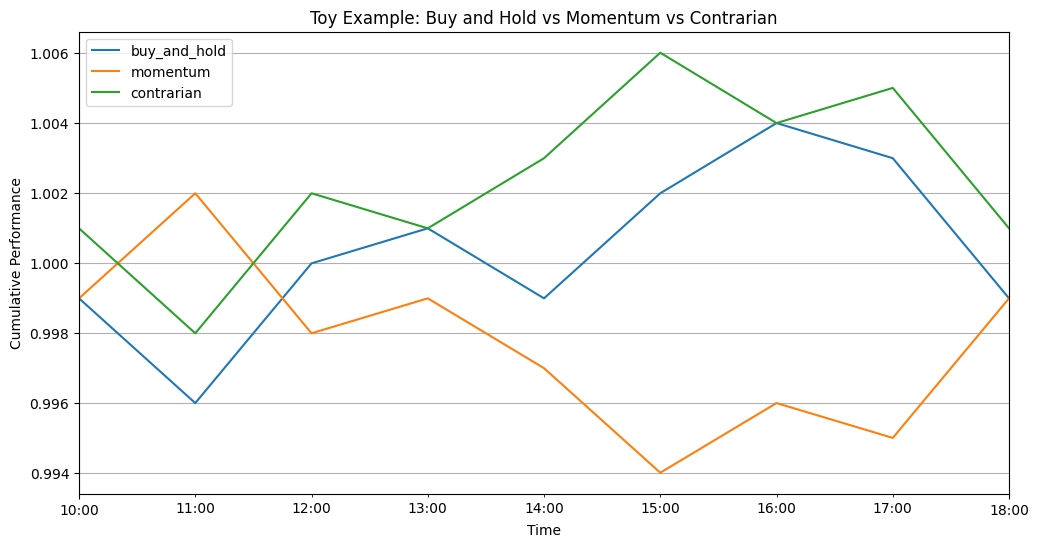

In [5]:
comparison = example.dropna().copy()

comparison["buy_and_hold"] = np.exp(comparison["return"].cumsum())
comparison["momentum"] = np.exp(comparison["momentum_strategy_1"].cumsum())
comparison["contrarian"] = np.exp(comparison["contrarian_strategy_1"].cumsum())

comparison[["buy_and_hold", "momentum", "contrarian"]].plot()
plt.title("Toy Example: Buy and Hold vs Momentum vs Contrarian")
plt.xlabel("Time")
plt.ylabel("Cumulative Performance")
plt.grid(True)
plt.show()


This is only a toy example. The purpose is not to prove that either strategy works. The purpose is to understand the position logic.


## Multi-Bar Momentum Using a Rolling Window

Instead of looking only at the most recent candle, we can look at the average return over the last few candles.

For example, a 3-bar momentum strategy checks whether the average return over the last 3 completed candles was positive or negative.

Rule:

- if the rolling mean return is positive, go long
- if the rolling mean return is negative, go short


In [6]:
window = 3

example["rolling_return_3"] = example["return"].rolling(window).mean()

example["momentum_position_3"] = np.sign(example["rolling_return_3"])
example["momentum_strategy_3"] = example["momentum_position_3"].shift(1) * example["return"]

example[["return", "rolling_return_3", "momentum_position_3", "momentum_strategy_3"]]


,return,rolling_return_3,momentum_position_3,momentum_strategy_3
hour,,,,
2024-01-01 09:00:00,0.002,NaN,NaN,NaN
2024-01-01 10:00:00,-0.001,NaN,NaN,NaN
2024-01-01 11:00:00,-0.003,-0.000667,-1.0,NaN
2024-01-01 12:00:00,0.004,0.000000,0.0,-0.004
2024-01-01 13:00:00,0.001,0.000667,1.0,0.000
2024-01-01 14:00:00,-0.002,0.001000,1.0,-0.002
2024-01-01 15:00:00,0.003,0.000667,1.0,0.003
2024-01-01 16:00:00,0.002,0.001000,1.0,0.002
2024-01-01 17:00:00,-0.001,0.001333,1.0,-0.001


Using a wider window makes the signal less sensitive to a single candle. A 3-bar momentum strategy asks whether the recent average return was positive or negative.


## Multi-Bar Contrarian Using a Rolling Window

The 3-bar contrarian strategy uses the same rolling return, but takes the opposite position.

Rule:

- if the recent average return is positive, go short
- if the recent average return is negative, go long


In [7]:
example["contrarian_position_3"] = -np.sign(example["rolling_return_3"])
example["contrarian_strategy_3"] = example["contrarian_position_3"].shift(1) * example["return"]

example[["return", "rolling_return_3", "contrarian_position_3", "contrarian_strategy_3"]]


,return,rolling_return_3,contrarian_position_3,contrarian_strategy_3
hour,,,,
2024-01-01 09:00:00,0.002,NaN,NaN,NaN
2024-01-01 10:00:00,-0.001,NaN,NaN,NaN
2024-01-01 11:00:00,-0.003,-0.000667,1.0,NaN
2024-01-01 12:00:00,0.004,0.000000,-0.0,0.004
2024-01-01 13:00:00,0.001,0.000667,-1.0,-0.000
2024-01-01 14:00:00,-0.002,0.001000,-1.0,0.002
2024-01-01 15:00:00,0.003,0.000667,-1.0,-0.003
2024-01-01 16:00:00,0.002,0.001000,-1.0,-0.002
2024-01-01 17:00:00,-0.001,0.001333,-1.0,0.001


Again, the only coding difference is the sign of the position.

Momentum:

```python
np.sign(rolling_return)
```

Contrarian:

```python
-np.sign(rolling_return)
```


## Visualise One-Bar versus Three-Bar Signals

Now visualise the difference between one-bar and three-bar momentum positions.


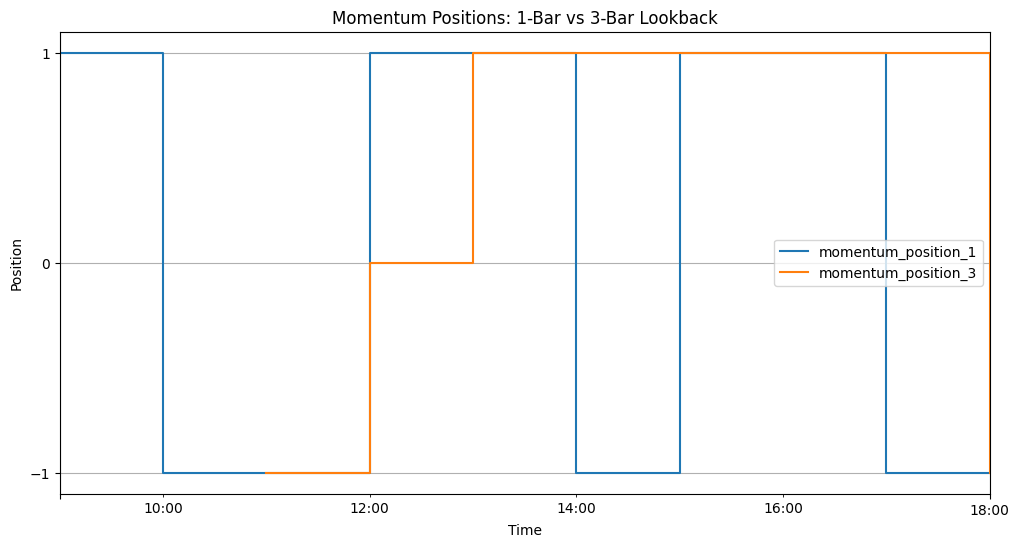

In [8]:
example[["momentum_position_1", "momentum_position_3"]].plot(drawstyle="steps-post")
plt.title("Momentum Positions: 1-Bar vs 3-Bar Lookback")
plt.xlabel("Time")
plt.ylabel("Position")
plt.yticks([-1, 0, 1])
plt.grid(True)
plt.show()


The one-bar signal can change direction very quickly. The three-bar signal is smoother because it depends on the average return over a wider window. However, even the three-bar version may still trade frequently.


## Real-Data Placeholder

In the next notebook, we will move from toy data to real historical price data.

For example, we may use one-hour EUR/USD data. The workflow will be:

1. import price data
2. calculate log returns
3. create momentum or contrarian positions
4. shift positions to avoid look-ahead bias
5. calculate strategy returns
6. compare cumulative performance
7. later include trading costs

We do not implement the full real-data backtest in this notebook yet.


## Final Summary

- Momentum strategies assume recent price movement will continue.
- Contrarian strategies assume recent price movement will reverse.
- A simple momentum position can be created with `np.sign(recent_return)`.
- A simple contrarian position can be created with `-np.sign(recent_return)`.
- The lookback window can be one candle, three candles, five candles, or another value.
- Wider windows create smoother signals but may react more slowly.
- Positions must be shifted before calculating strategy returns to avoid look-ahead bias.
- Simple standalone momentum and contrarian strategies can trade excessively.
- Trading costs are likely to be very important, especially on short timeframes.
- The next notebook will start coding the strategy using real price data.
